In [ ]:
# =========================
# 📦 IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# 📂 CARGA DE ARCHIVOS
# =========================
FILES = [f'data/AVAILABILITY-data ({i}).csv' for i in range(1, 101)]

print("Cantidad de archivos:", len(FILES))
print("Primeros archivos:", FILES[:5])

# =========================
# ⚙️ PROCESAMIENTO
# =========================
from data_processor import DataProcessor

processor = DataProcessor(FILES)
df = processor.cargar()

# =========================
# 🧠 VERIFICACIÓN
# =========================
print("\nDimensiones del dataset:", df.shape)
df.head()

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 34539 entries, 0 to 362
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     34539 non-null  datetime64[ns]
 1   availability  34539 non-null  int64         
 2   source        34539 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.1+ MB


,timestamp,availability
count,34539,3.453900e+04
mean,2026-02-03 19:15:40.914618112,3.101572e+06
min,2026-02-01 06:59:40,0.000000e+00
25%,2026-02-02 12:52:05,1.379717e+06
50%,2026-02-03 18:00:00,3.370523e+06
75%,2026-02-04 23:52:15,4.865762e+06
max,2026-02-06 11:00:00,6.107574e+06
std,NaN,1.935103e+06


In [4]:
print("Media:", df['availability'].mean())
print("Desviación estándar:", df['availability'].std())
print("Mínimo:", df['availability'].min())
print("Máximo:", df['availability'].max())

Media: 3101572.2233417295
Desviación estándar: 1935103.0591343946
Mínimo: 0
Máximo: 6107574


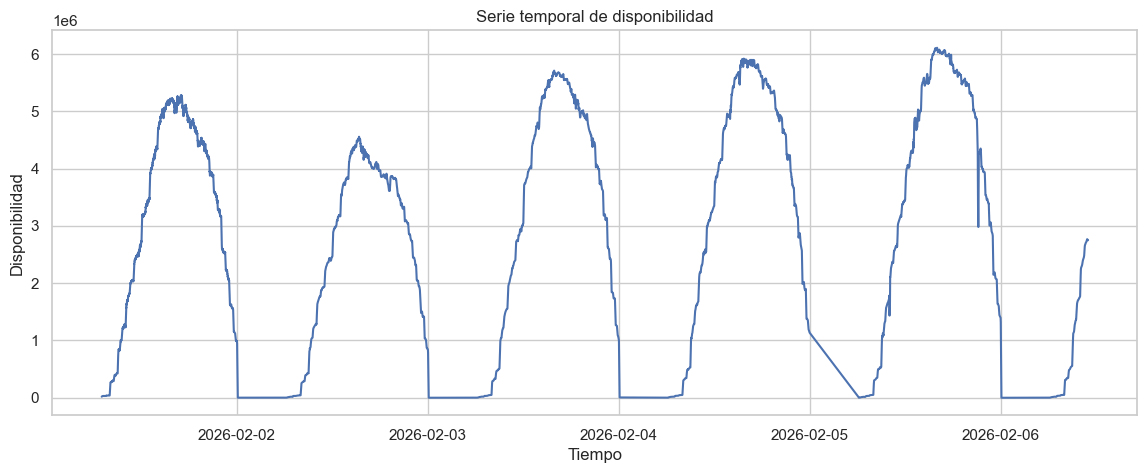

In [5]:
plt.figure(figsize=(14,5))
plt.plot(df['timestamp'], df['availability'])
plt.title("Serie temporal de disponibilidad")
plt.xlabel("Tiempo")
plt.ylabel("Disponibilidad")
plt.show()

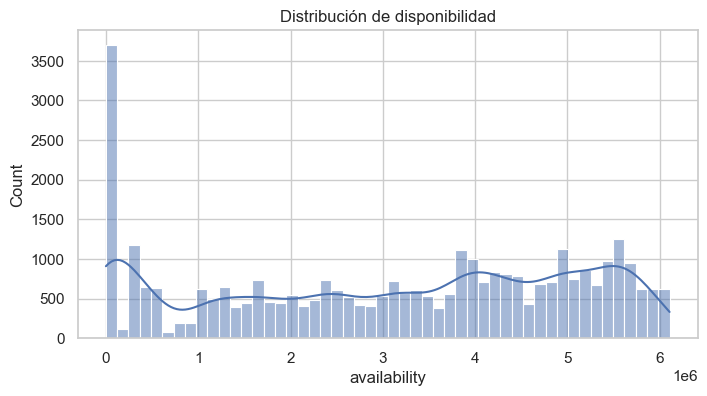

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(df['availability'], bins=50, kde=True)
plt.title("Distribución de disponibilidad")
plt.show()

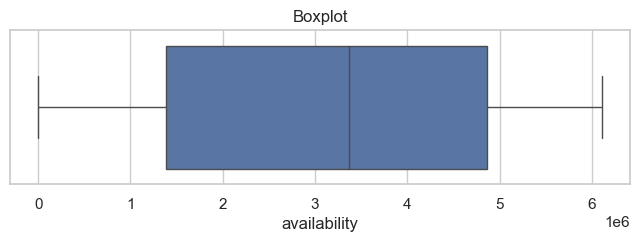

In [7]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['availability'])
plt.title("Boxplot")
plt.show()

In [8]:
Q1 = df['availability'].quantile(0.25)
Q3 = df['availability'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df['availability'] < Q1 - 1.5*IQR) |
    (df['availability'] > Q3 + 1.5*IQR)
]

print("Cantidad de outliers:", len(outliers))
outliers.head()

Cantidad de outliers: 0


,timestamp,availability,source


In [9]:
df['delta'] = df['availability'].diff()

threshold = df['delta'].quantile(0.05)
drops = df[df['delta'] < threshold]

print("Cantidad de caídas:", len(drops))

Cantidad de caídas: 1727


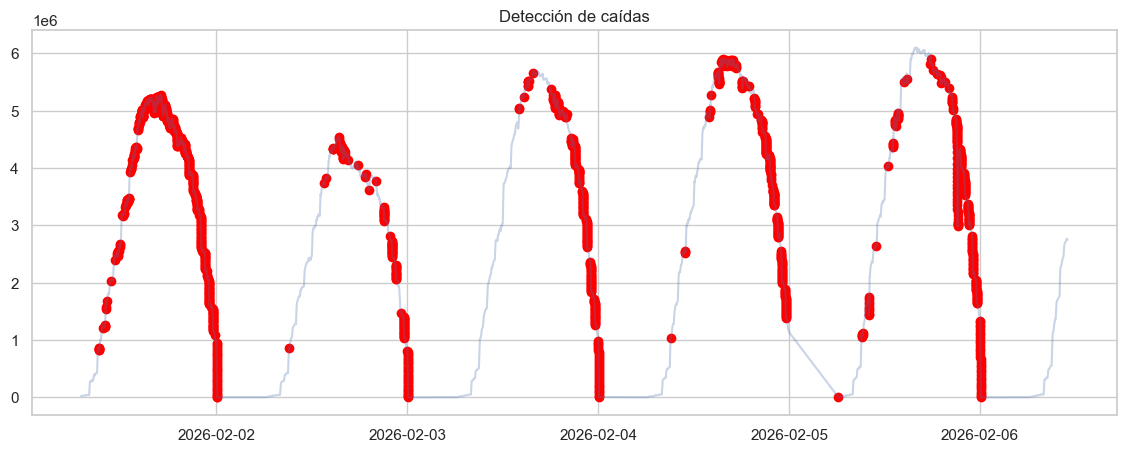

In [10]:
plt.figure(figsize=(14,5))
plt.plot(df['timestamp'], df['availability'], alpha=0.3)
plt.scatter(drops['timestamp'], drops['availability'], color='red')
plt.title("Detección de caídas")
plt.show()

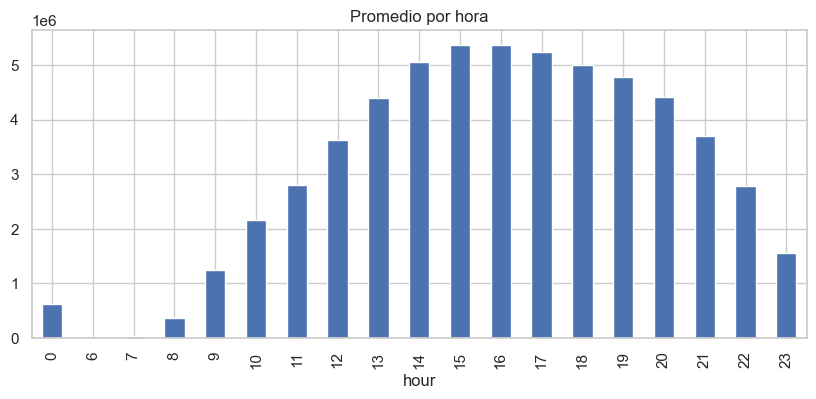

In [11]:
df['hour'] = df['timestamp'].dt.hour

plt.figure(figsize=(10,4))
df.groupby('hour')['availability'].mean().plot(kind='bar')
plt.title("Promedio por hora")
plt.show()

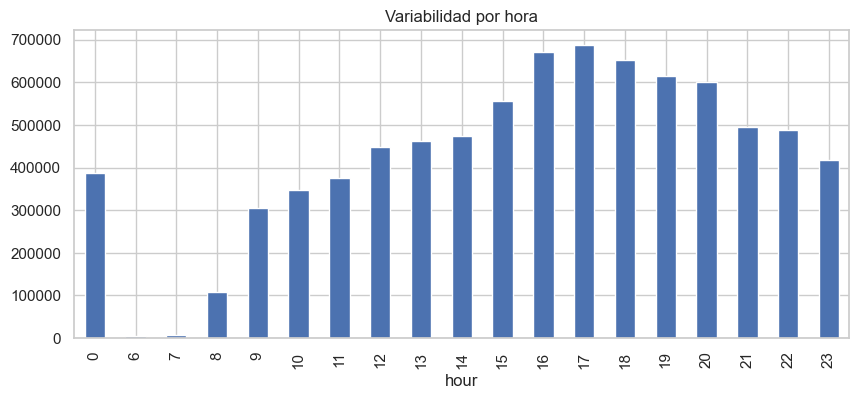

In [12]:
plt.figure(figsize=(10,4))
df.groupby('hour')['availability'].std().plot(kind='bar')
plt.title("Variabilidad por hora")
plt.show()

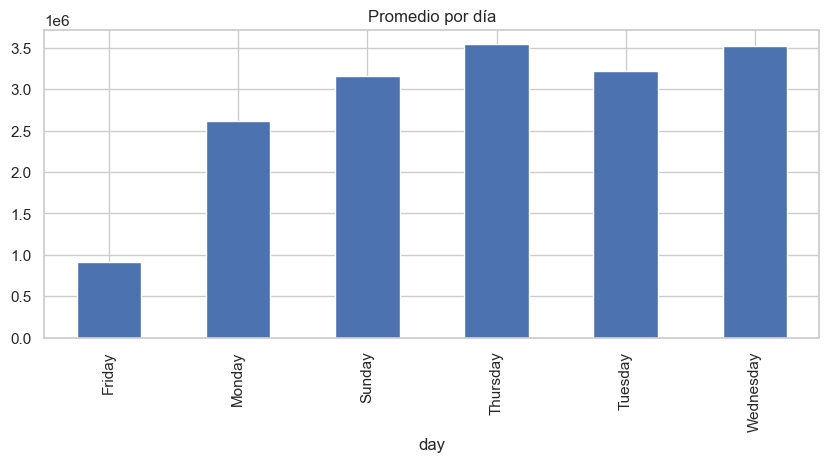

In [13]:
df['day'] = df['timestamp'].dt.day_name()

plt.figure(figsize=(10,4))
df.groupby('day')['availability'].mean().plot(kind='bar')
plt.title("Promedio por día")
plt.show()

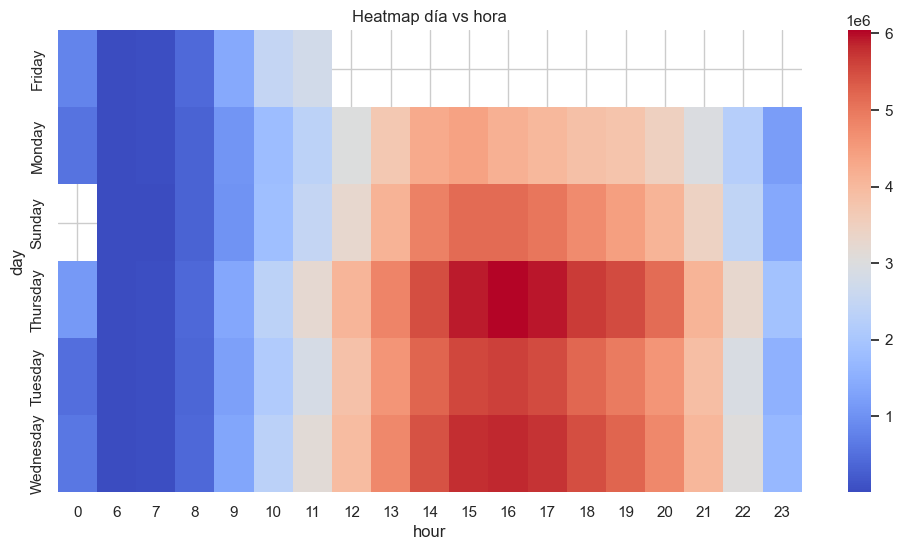

In [14]:
pivot = df.pivot_table(
    values='availability',
    index='day',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Heatmap día vs hora")
plt.show()

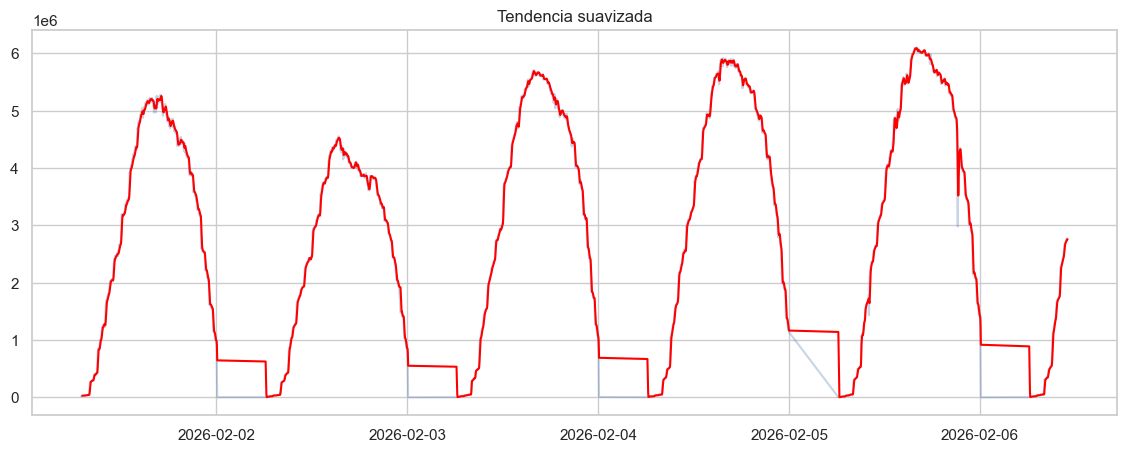

In [15]:
df['rolling_mean'] = df['availability'].rolling(window=50).mean()

plt.figure(figsize=(14,5))
plt.plot(df['timestamp'], df['availability'], alpha=0.3)
plt.plot(df['timestamp'], df['rolling_mean'], color='red')
plt.title("Tendencia suavizada")
plt.show()

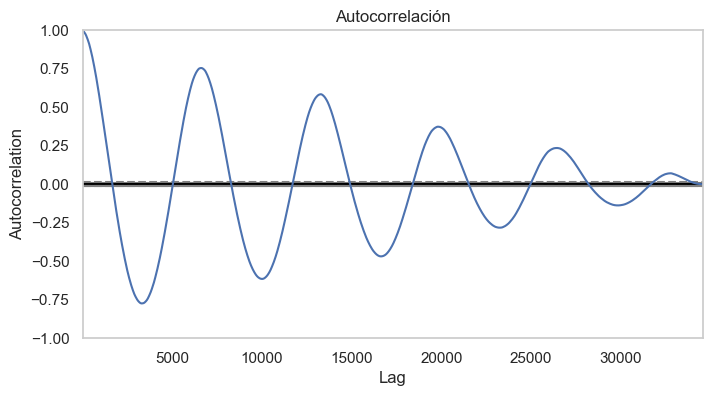

In [17]:
from pandas.plotting import autocorrelation_plot
plt.figure(figsize=(8,4))
autocorrelation_plot(df['availability'])
plt.title("Autocorrelación")
plt.show()

In [18]:
from scipy.stats import zscore
df['zscore'] = zscore(df['availability'])

anomalies = df[df['zscore'].abs() > 3]

print("Anomalías detectadas:", len(anomalies))

Anomalías detectadas: 0


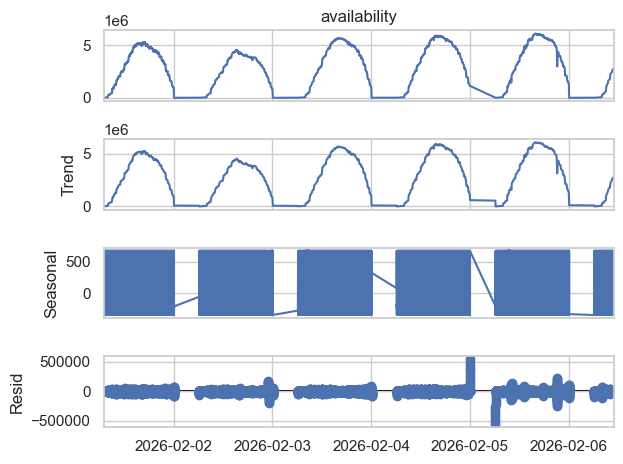

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_temp = df.set_index('timestamp')

result = seasonal_decompose(df_temp['availability'], period=24)

result.plot()
plt.show()